![banner](../../../../docs/figs/brand_identity/banner.png)

# Week 8: Street-View Image Segmentation

## Lesson overview

Use a pre-trained model to label regions such as roads, buildings, and pedestrians in street-view images. The inputs are six images included in the repository; the output assigns a class to each pixel.

**By the end, you can:** read the color legend; compare an original image with its segmentation; and explain why boundaries or small objects may be misclassified.

**Before you begin:** The local example images need no download. The first model load needs an internet connection and model weights. Google Maps downloads are optional and require your own API credentials; charges may apply.

<p align="center"><img src="sample_segmentation_with_model.svg" alt="Real street-view photograph passes through a SegFormer-B5 model to its predicted Cityscapes pixel-label map and class legend" width="100%"><br><em>Figure 1. The included street-view sample (left) passes through SegFormer-B5 to produce the saved prediction (right). Both image panels come from this notebook's result below; colours indicate predicted classes, not ground-truth labels.</em></p>

**Read the pair:** Compare the same scene in both panels. The large purple foreground is predicted as road, the bright pink regions as sidewalk, and the dark grey regions as building. Use the legend for other colours, then look for a boundary or small object the model may have labelled incorrectly.

## Local street-view images first

The repository includes six sample street-view images in `weekly_scripts/wip/week8/svi_segmentation/images/` and a single `sample.jpeg`. Use these local files to learn semantic segmentation without a Google key. The Cityscapes SegFormer model weights and processor download on first use and are cached under the repository model cache. Google Street View download cells are an optional extension and require a configured API key, internet, and may incur charges. Segmentation outputs go to the lesson's `segmentations/` folder.


## Step 0: Initialize model

Load the pre-trained segmentation model and image processor. The first run downloads model files; this step prepares the model but does not process any street images yet.

## Step 1 — Segment the included local image subset

Run segmentation on the six street-view images included in the repository. Check the input file list and where outputs are saved.

Using lat37.774900_lon-122.417400_hdg0.jpg; 6 local samples available


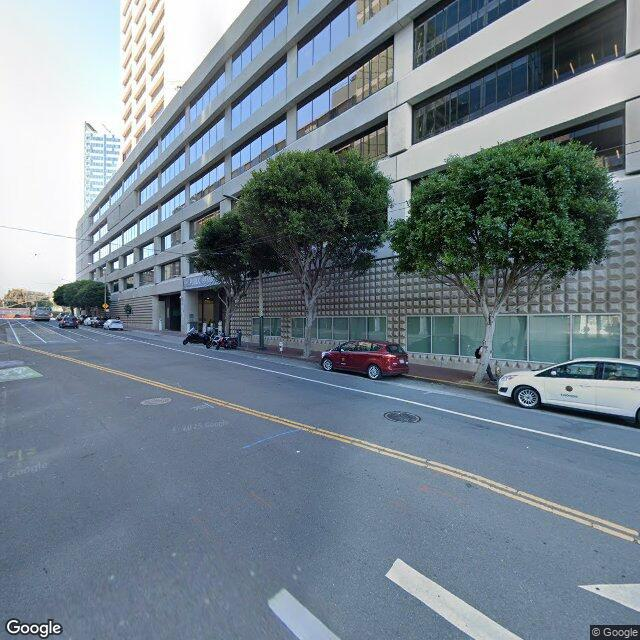

In [2]:
from pathlib import Path
from PIL import Image
from ccai9012.paths import WEEKLY_SCRIPTS_DIR

LOCAL_IMAGE_DIR = WEEKLY_SCRIPTS_DIR / "wip" / "week8" / "svi_segmentation" / "images"
local_image_paths = sorted(LOCAL_IMAGE_DIR.glob("*.jpg"))
if not local_image_paths:
    raise FileNotFoundError(f"No local SVI samples found in {LOCAL_IMAGE_DIR}")
image = Image.open(local_image_paths[0]).convert("RGB")
print(f"Using {local_image_paths[0].name}; {len(local_image_paths)} local samples available")
image

In [4]:
from pathlib import Path
from ccai9012.paths import ensure_output_dir
OUTPUT_DIR = ensure_output_dir(Path.cwd())
print(f"Segmentation outputs will be saved under {OUTPUT_DIR}")

Segmentation outputs will be saved under /Users/kanxuanhe/Document/250421_AI_course/ccai9012/weekly_scripts/wip/week8/svi_segmentation/output


In [10]:
from ccai9012 import svi_utils
from ccai9012.paths import MODELS_DIR

In [12]:
# Load the pre-trained SegFormer-B5 model and image processor
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation

model_id = "nvidia/segformer-b5-finetuned-cityscapes-1024-1024"
model = AutoModelForSemanticSegmentation.from_pretrained(model_id, cache_dir=str(MODELS_DIR))
processor = AutoImageProcessor.from_pretrained(model_id)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/339M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/273 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Step 2: Inspect one street-view prediction

Compare one image with its result: the original shows the scene, and different colors mark the classes identified by the model. Use the legend to read the colors.

**Read the overlay:** Choose one road edge and one building boundary. Are their predicted colours aligned with the visible objects? The colours represent model classes, not measured surfaces or ground-truth labels.


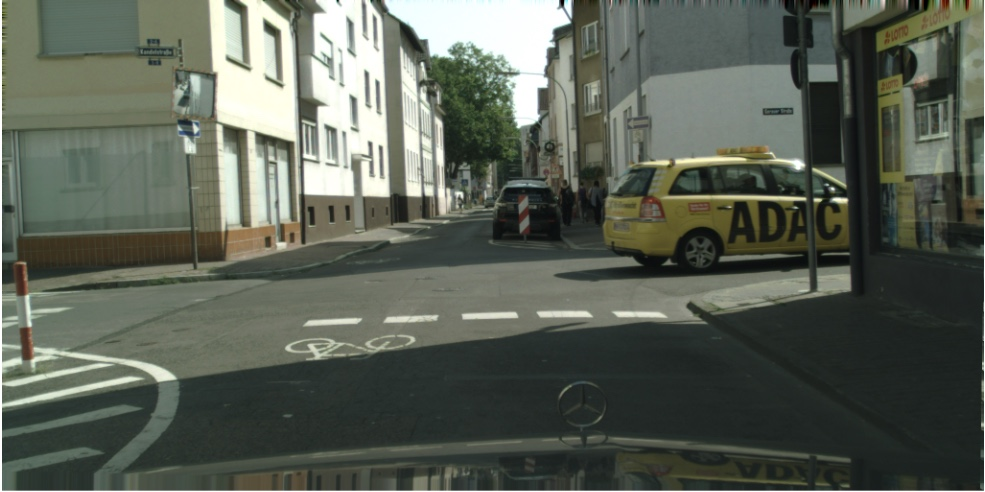

In [3]:
from PIL import Image

image = Image.open("sample.jpeg")
image

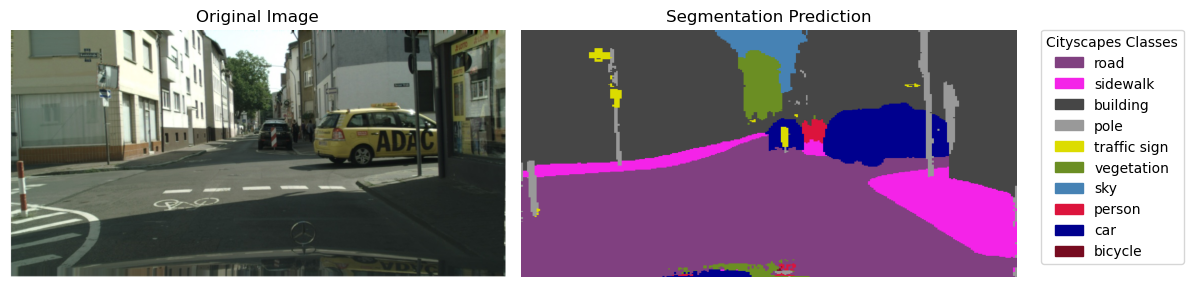

In [4]:
# Predict segmentation and convert to numpy
mask_np = svi_utils.segment_and_save_images(image, processor, model)

# Visualize the original image and predicted segmentation results
svi_utils.visualize_segmentation_pair(image, mask_np, show_legend=True)

## Optional extension — download more SVI from Google Maps

This is an optional online-data step. Run it only after configuring a Google Maps API key. Check the coordinates and downloaded images before sending them to the segmentation step.

In [5]:
# Initialize downloader for Google Map API
downloader = svi_utils.GoogleSVIDownloader()

Enter your Google Map API key:  ········


In [6]:
# Check if Street View Image (SVI) is available at a specific location

lat, lon = 37.7749, -122.4194  # Example: San Francisco coordinates
available = downloader.is_svi_available(lat, lon)
print(f"SVI available at {lat}, {lon}? {available}")

SVI available at 37.7749, -122.4194? False


In [7]:
# Download a single Street View Image
image = downloader.download_svi(lat, lon, heading=0, pitch=0, fov=90, size="640x640", save=True)
if image:
    display(image)  # Display the image

Failed to download SVI at (37.7749, -122.4194), status code: 403


In [12]:
# Batch download SVI images over the grid region
svi_images = downloader.download_grid_svis(lat_start=37.7749, lon_start=-122.4194,
                                           rows=2, cols=3, delta=0.001,
                                           heading=0, pitch=0, fov=90, size="640x640")

Saved SVI: images/lat37.774900_lon-122.419400_hdg0.jpg
Saved SVI: images/lat37.774900_lon-122.418400_hdg0.jpg
Saved SVI: images/lat37.774900_lon-122.417400_hdg0.jpg
Saved SVI: images/lat37.775900_lon-122.419400_hdg0.jpg
Saved SVI: images/lat37.775900_lon-122.418400_hdg0.jpg
Saved SVI: images/lat37.775900_lon-122.417400_hdg0.jpg


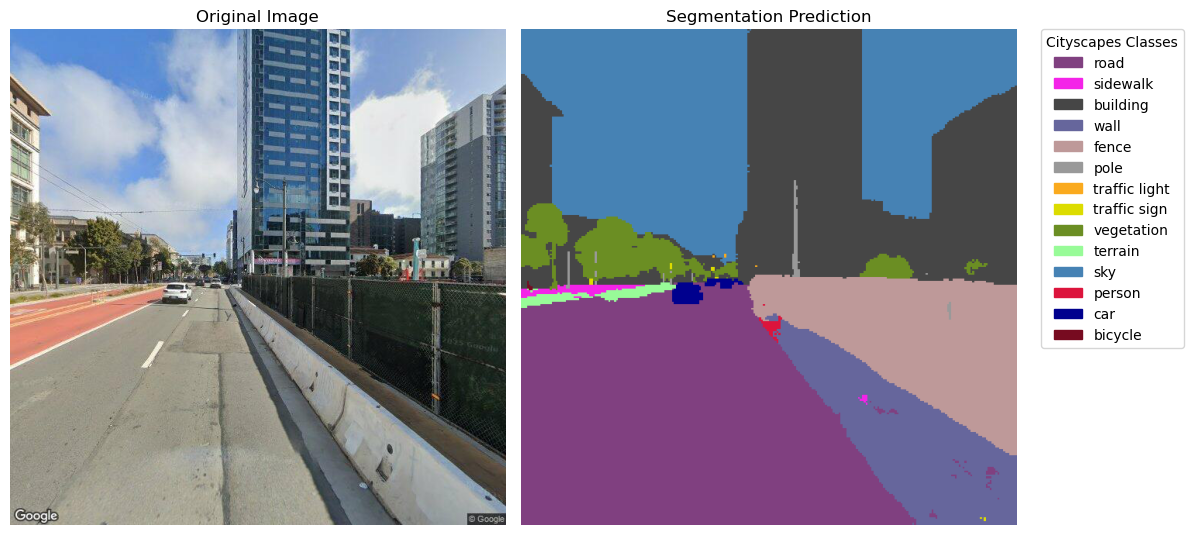

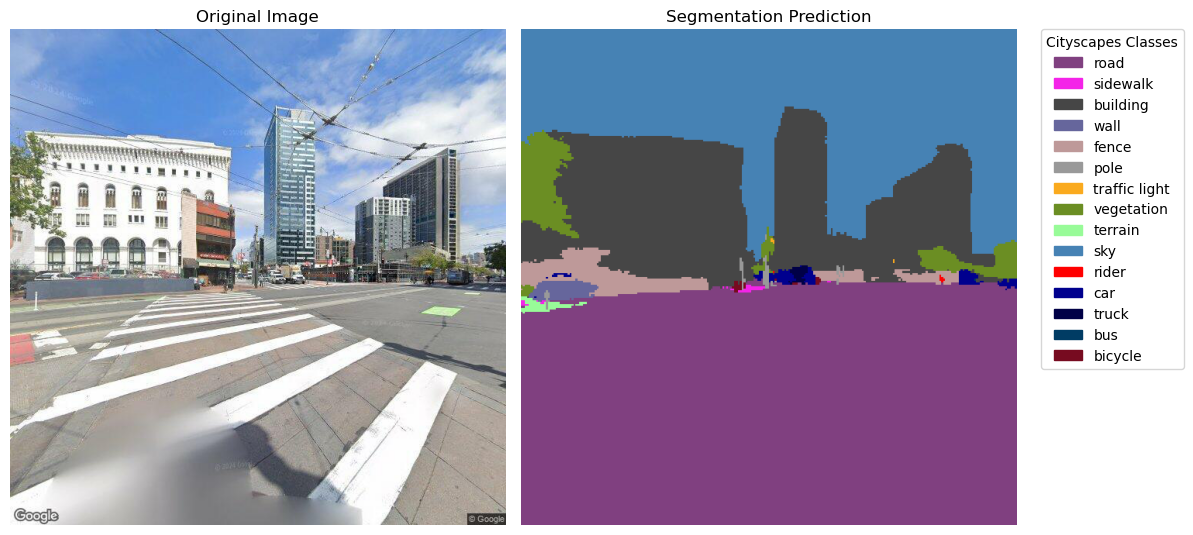

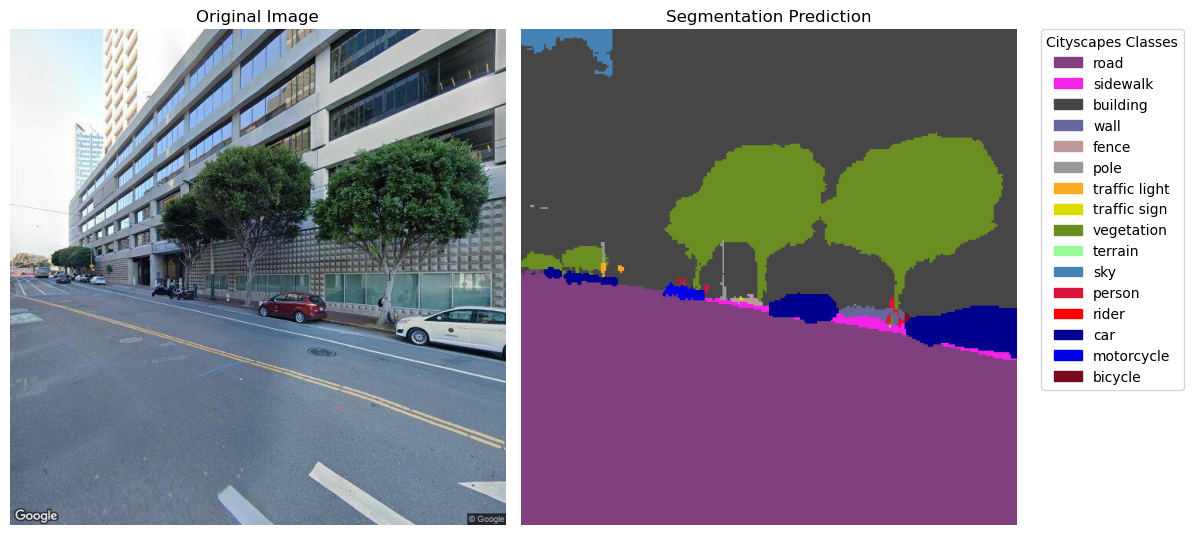

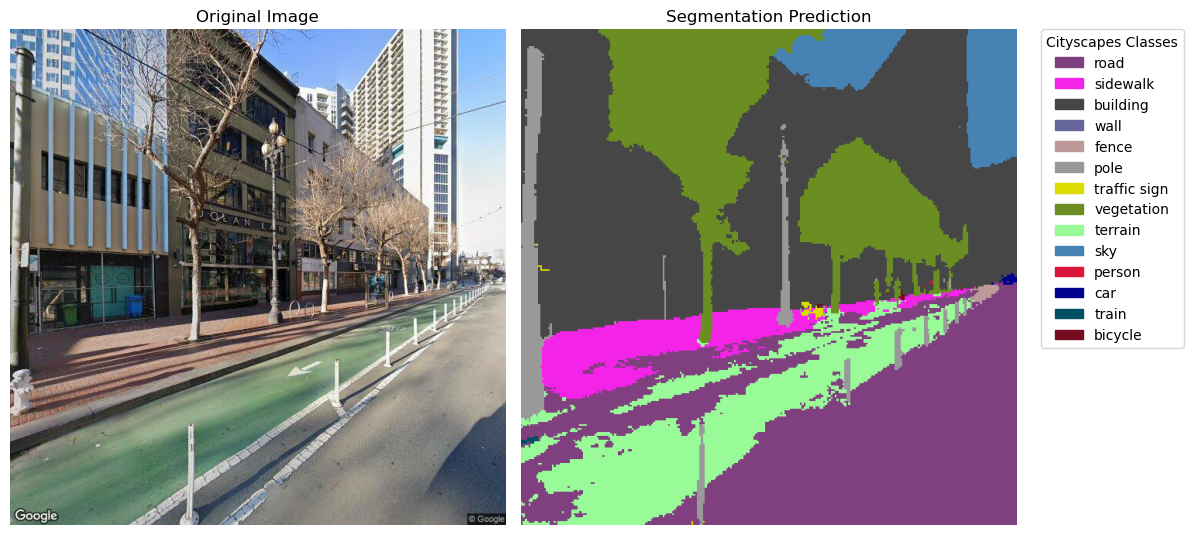

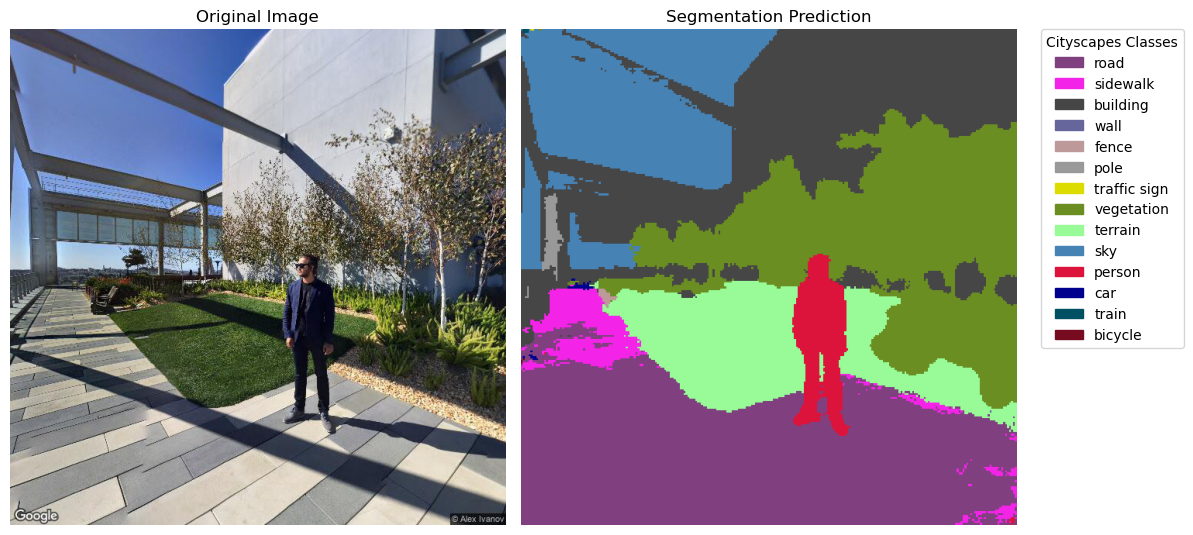

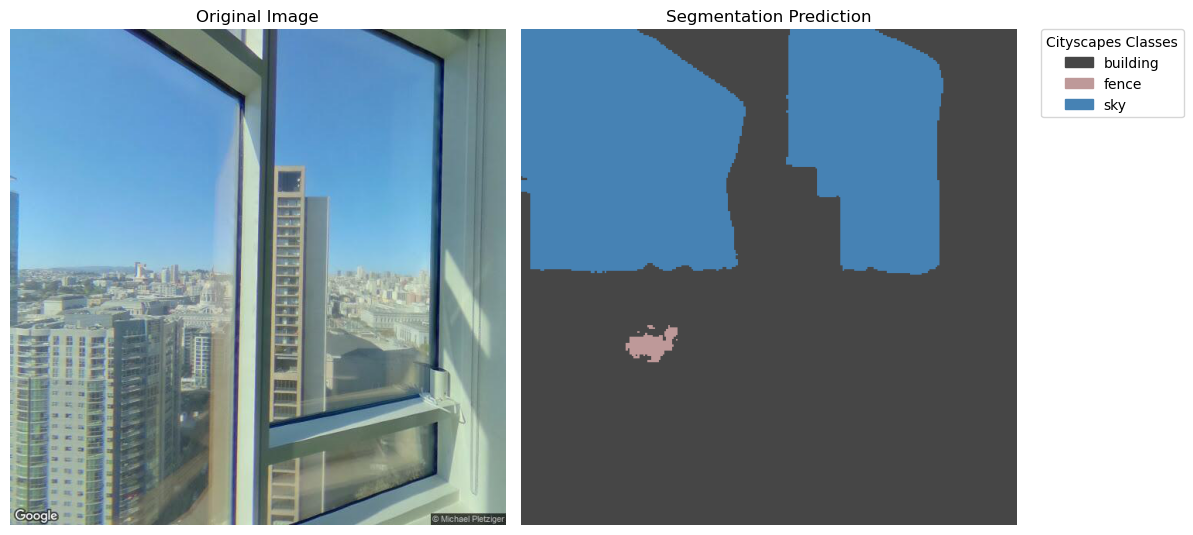

In [14]:
# Segment the downloaded SVIs and visualize
svi_utils.batch_segment_and_visualize(
    save_dir="images",
    output_dir=str(OUTPUT_DIR / "segmentations"),
    processor=processor,
    model=model,
    max_visualize=10,
)

## What to take away

A segmentation map assigns a class to each pixel. **Try next:** Check more street scenes. **Limit:** The model’s training data and available classes affect results at new locations.